In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import torch
from matplotlib.colors import to_hex
from scipy.optimize import linear_sum_assignment

sys.path.append('../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_RUNS      = 5
NUM_EPOCHS  = 200
VALIDATE_EVERY = 50
BATCH_SIZE  = 4096
LATENT_DIM  = 16
PATIENCE    = 20
RESULTS_DIR = "results/benchmarking"
N_CLUSTERS  = 10

# Metrics tracked for scoring and box plots
METRIC_COLS = [
    'cf_ate_pearson_r',
    'cluster_f1',
    'cluster_ari',
    'cluster_ami',
    'cluster_silhouette',
    'cluster_linear_probe',
    'cluster_knn_purity',
]

# (model_key, display_name, method-specific kwargs)
METHODS = [
    ("vae",           "sherlock",      {},  500),
    ("svae",          "sVAE",          {"sparse_mask_penalty": 10.0},  NUM_EPOCHS),
    ("cvae",          "cVAE",          {},  NUM_EPOCHS),
    ("contrastivevi", "contrastiveVI", {},  NUM_EPOCHS),
    ("scgen",         "scgen",         {},  NUM_EPOCHS),
]

os.makedirs(f"{RESULTS_DIR}/models",   exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/figures",  exist_ok=True)

print(f"Device: {DEVICE}  Results: {RESULTS_DIR}")

Device: cuda  Results: results/benchmarking


## Data loading and ground-truth ATE

In [4]:
data = slk.datasets.replogle()

slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)
treat_effect_adata = data.uns['treat_effect']
print(f"Cells: {data.n_obs}  Genes: {data.n_vars}  Perturbations: {data.obs['pert'].nunique()}")

100%|██████████| 681/681 [00:09<00:00, 75.61it/s]

Cells: 118641  Genes: 1185  Perturbations: 682


## Pathway annotations for clustering evaluation

In [5]:
pathways = data.uns['pathways']

all_genes_filtered = [
    gene
    for genes in pathways.values()
    for gene in genes
    if gene != 'LSM5'
]

gene_to_pathway = {
    gene: pathway
    for pathway, genes in pathways.items()
    for gene in genes
    if gene != 'LSM5'
}
pathway_df_indexed = pd.DataFrame.from_dict(
    gene_to_pathway, orient='index', columns=['pathway']
)
pathway_df_indexed.index.name = 'gene'

print(f"Pathway genes: {len(all_genes_filtered)}  Pathways: {len(pathways)}")

Pathway genes: 335  Pathways: 8


## Benchmark loop

Each method is trained `N_RUNS` times independently. The best-scoring run
per method is saved to `results/models/`. Metrics are computed after training
using the proper counterfactual ATE protocol; the clustering cut is chosen
automatically via the elbow method.

In [6]:
records         = []
best_run_out    = {}   # method → out dict of best single run
best_run_model  = {}   # method → model of best single run
best_run_score  = {}   # method → avg metric score of best single run

for model_key, display_name, extra_kwargs, EPOCHS, in METHODS:
    print(f"\n{'='*60}\n{display_name}  ({N_RUNS} runs)\n{'='*60}")
    best_run_score[display_name] = -np.inf

    for run in range(N_RUNS):
        print(f"\n  -- {display_name} run {run + 1}/{N_RUNS} --")

        out = slk.tl.run(
            data,
            model=model_key,
            batch_size=BATCH_SIZE,
            num_epochs=EPOCHS,
            device=DEVICE,
            latent_dim=LATENT_DIM,
            patience=PATIENCE,
            validate_every=VALIDATE_EVERY,
            seed=run,
            **extra_kwargs,
        )
        model = out['model']

        metrics = slk.tl.evaluate_model(
            model,
            data,
            treat_effect_adata,
            pathway_df_indexed,
            all_genes_filtered,
            n_clusters=N_CLUSTERS,
            device=DEVICE,
            use_rho=False,
        )

        # Track best run for this method
        run_avg = float(metrics['cf_ate_pearson_r'])
        if run_avg > best_run_score[display_name]:
            best_run_score[display_name] = run_avg
            best_run_out[display_name]   = out
            best_run_model[display_name] = model

        metrics['method'] = display_name
        metrics['run']    = run
        records.append(metrics)

        for k, v in metrics.items():
            if k not in ('method', 'run'):
                val_str = f"{v:.4f}" if np.isfinite(float(v)) else "NaN"
                print(f"    {k:30s} = {val_str}")

    # Save best run model for this method
    save_path = f"{RESULTS_DIR}/models/{display_name}_best.pth"
    slk.tl.save_results(best_run_out[display_name], save_path)
    print(f"\n  Saved best {display_name} model → {save_path}")

results_df = pd.DataFrame(records)
print("\nDone.")


sherlock  (5 runs)

  -- sherlock run 1/5 --
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [22:44<00:00,  2.73s/it, ATE=0.4382, CE=3.9710, ELBO=1824.1674, KLw=1.00, R2_ntc=0.9664, R2_p=0.9627, acc=0.204, pi25=0.01, pi99=1.00, tau=0.300]


    cf_ate_pearson_r               = 0.4285
    cluster_accuracy               = 0.9761
    cluster_precision              = 0.9756
    cluster_recall                 = 0.9780
    cluster_f1                     = 0.9752
    cluster_ari                    = 0.9173
    cluster_ami                    = 0.9270
    cluster_homogeneity            = 0.9729
    cluster_completeness           = 0.8922
    cluster_v_measure              = 0.9308
    cluster_silhouette             = 0.4022
    cluster_purity                 = 0.9761
    cluster_knn_purity             = 0.9863
    cluster_linear_probe           = 0.9940
    rho_z_pearson_r                = 0.7636

  -- sherlock run 2/5 --
Training VAE on cuda …


Epochs: 100%|██████████| 500/500 [22:03<00:00,  2.65s/it, ATE=0.4204, CE=4.0389, ELBO=1824.3575, KLw=1.00, R2_ntc=0.9602, R2_p=0.9596, acc=0.192, pi25=0.01, pi99=1.00, tau=0.300]


    cf_ate_pearson_r               = 0.4136
    cluster_accuracy               = 0.9701
    cluster_precision              = 0.9802
    cluster_recall                 = 0.9651
    cluster_f1                     = 0.9710
    cluster_ari                    = 0.8997
    cluster_ami                    = 0.9078
    cluster_homogeneity            = 0.9558
    cluster_completeness           = 0.8731
    cluster_v_measure              = 0.9126
    cluster_silhouette             = 0.3901
    cluster_purity                 = 0.9701
    cluster_knn_purity             = 0.9839
    cluster_linear_probe           = 0.9881
    rho_z_pearson_r                = 0.6969

  -- sherlock run 3/5 --
Training VAE on cuda …


...

Early stopping at epoch 190 (best loss=116.0579)
    cf_ate_pearson_r               = 0.7782
    cluster_accuracy               = 0.8716
    cluster_precision              = 0.8161
    cluster_recall                 = 0.8212
    cluster_f1                     = 0.8113
    cluster_ari                    = 0.8375
    cluster_ami                    = 0.8291
    cluster_homogeneity            = 0.8652
    cluster_completeness           = 0.8126
    cluster_v_measure              = 0.8380
    cluster_silhouette             = 0.2144
    cluster_purity                 = 0.8896
    cluster_knn_purity             = 0.9582
    cluster_linear_probe           = 0.9881
    rho_z_pearson_r                = 1.0000

  -- scgen run 4/5 --


scGEN: 100%|██████████| 200/200 [08:12<00:00,  2.46s/it, ATE=0.7690, R2=0.9424, loss=116.4492]


    cf_ate_pearson_r               = 0.7822
    cluster_accuracy               = 0.8985
    cluster_precision              = 0.8704
    cluster_recall                 = 0.8503
    cluster_f1                     = 0.8373
    cluster_ari                    = 0.8658
    cluster_ami                    = 0.8501
    cluster_homogeneity            = 0.8761
    cluster_completeness           = 0.8407
    cluster_v_measure              = 0.8580
    cluster_silhouette             = 0.2406
    cluster_purity                 = 0.8985
    cluster_knn_purity             = 0.9606
    cluster_linear_probe           = 0.9821
    rho_z_pearson_r                = 1.0000

  -- scgen run 5/5 --


scGEN: 100%|██████████| 200/200 [07:57<00:00,  2.39s/it, ATE=0.7769, R2=0.9469, loss=116.5647]


    cf_ate_pearson_r               = 0.7820
    cluster_accuracy               = 0.8836
    cluster_precision              = 0.8691
    cluster_recall                 = 0.8201
    cluster_f1                     = 0.8217
    cluster_ari                    = 0.7689
    cluster_ami                    = 0.8061
    cluster_homogeneity            = 0.8502
    cluster_completeness           = 0.7847
    cluster_v_measure              = 0.8162
    cluster_silhouette             = 0.2013
    cluster_purity                 = 0.8836
    cluster_knn_purity             = 0.9528
    cluster_linear_probe           = 0.9851
    rho_z_pearson_r                = 1.0000

  Saved best scgen model → results/benchmarking/models/scgen_best.pth

Done.


## Results summary

In [7]:
summary = (
    results_df
    .groupby('method')[METRIC_COLS]
    .agg(['mean', 'std'])
    .round(4)
)
# Preserve METHODS order
method_order = [m[1] for m in METHODS]
summary = summary.reindex([m for m in method_order if m in summary.index])
print(summary.to_string())

              cf_ate_pearson_r         cluster_f1         cluster_ari         cluster_ami         cluster_silhouette         cluster_linear_probe         cluster_knn_purity        
                          mean     std       mean     std        mean     std        mean     std               mean     std                 mean     std               mean     std
method                                                                                                                                                                              
sherlock                0.4311  0.0384     0.9431  0.0784      0.8668  0.1094      0.9072  0.0452             0.3874  0.0111               0.9916  0.0033             0.9830  0.0031
sVAE                    0.2701  0.0070     0.8689  0.1086      0.7027  0.0991      0.8000  0.0953             0.2922  0.0351               0.9899  0.0016             0.9436  0.0197
cVAE                    0.4250  0.0250     0.8406  0.0554      0.7115  0.0535      0.8399  0.05

## Box plots

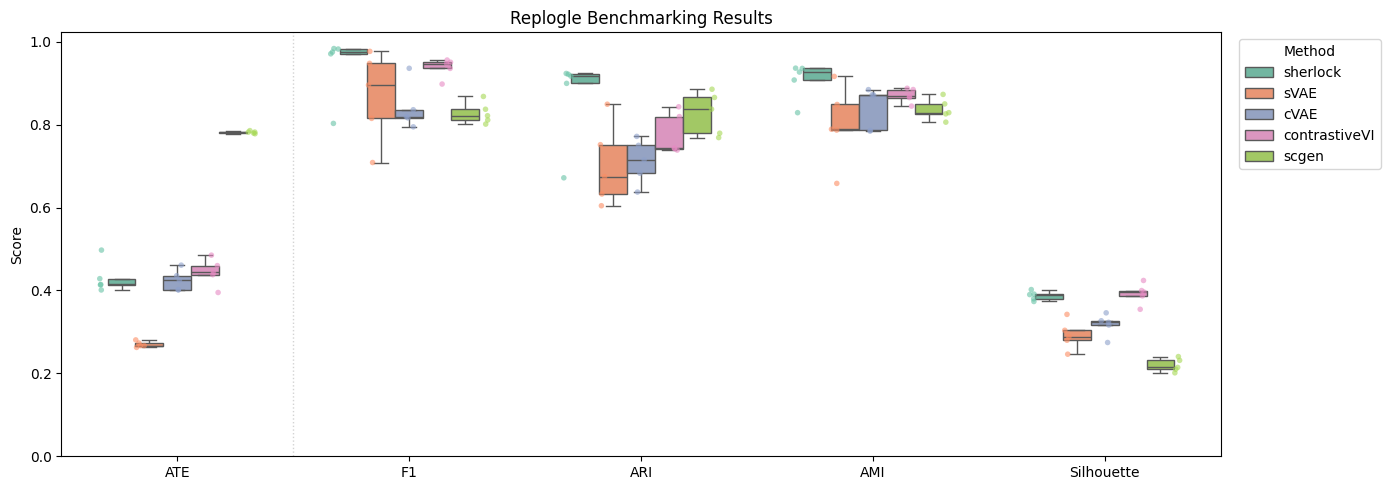

In [ ]:
label_map = {
    'cf_ate_pearson_r':   'ATE',
    'cluster_f1':         'F1',
    'cluster_ari':        'ARI',
    'cluster_ami':        'AMI',
    'cluster_silhouette': 'Silhouette',
    # 'cluster_linear_probe': 'Linear\nProbe',
    # 'cluster_knn_purity': 'kNN\nPurity',
}

METRIC_COLS_PLOT = [
    m for m in METRIC_COLS
    if m not in ['cluster_linear_probe', 'cluster_knn_purity']
]

method_order = [m[1] for m in METHODS]

df_melted = results_df.melt(
    id_vars='method', value_vars=METRIC_COLS_PLOT, var_name='metric', value_name='value'
)
df_melted['metric_label'] = pd.Categorical(
    df_melted['metric'].map(label_map),
    categories=[label_map[m] for m in METRIC_COLS_PLOT],
    ordered=True,
)
df_melted['method'] = pd.Categorical(
    df_melted['method'], categories=method_order, ordered=True
)
df_melted['value'] = df_melted['value'].clip(lower=0)

fig, ax = plt.subplots(figsize=(14, 5))

sns.boxplot(
    data=df_melted,
    x='metric_label',
    y='value',
    hue='method',
    palette='Set2',
    width=0.6,
    showfliers=False,
    ax=ax,
)

sns.stripplot(
    data=df_melted,
    x='metric_label',
    y='value',
    hue='method',
    palette='Set2',
    dodge=True,
    size=4,
    alpha=0.6,
    legend=False,
    ax=ax,
)

ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_title('Replogle Benchmarking Results')
ax.legend(title='Method', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_ylim(bottom=0)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# Separator between ATE and clustering metrics
ax.axvline(0.5, color='lightgray', linewidth=1.0, linestyle=':')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/benchmark_boxplot.png', bbox_inches='tight')
plt.show()

## Per-method best models — latent space UMAPs

For each method, re-eval the best run, compute UMAP on non-NTC cells, cluster the
pathway-gene subset of z_corr (maxclust), align predicted clusters to true pathways
via Hungarian matching, and save the figure.


Generating figure for best sherlock model


/var/tmp/ipykernel_2642945/2831952657.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/sherlock_best_umap.png


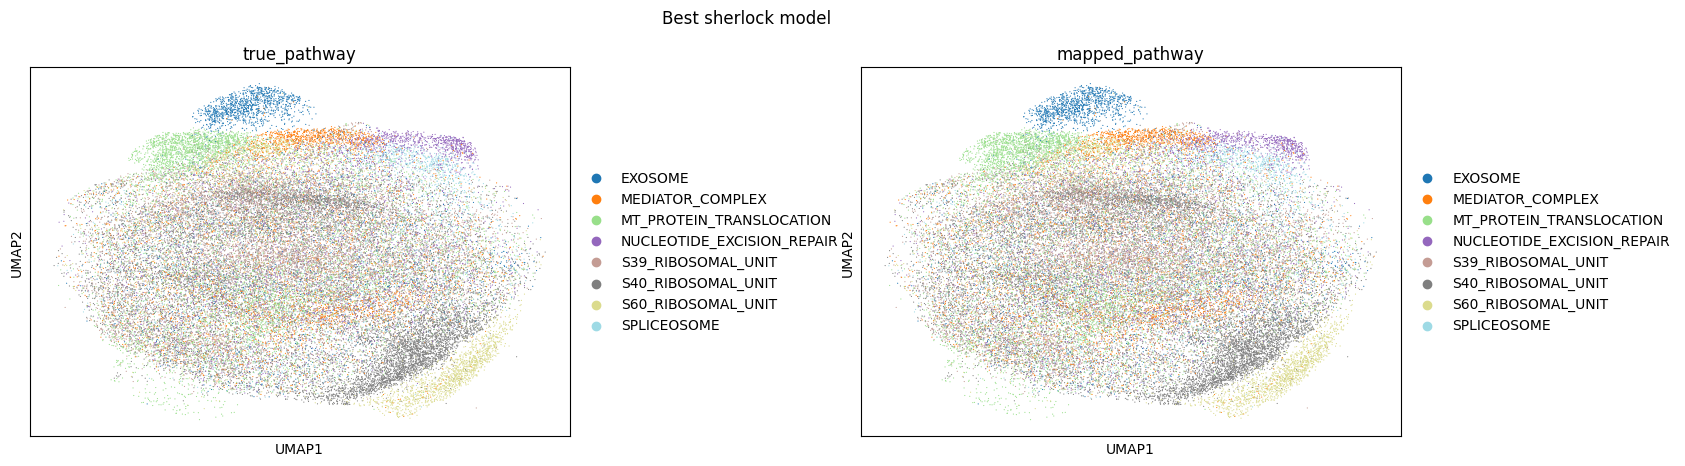


Generating figure for best sVAE model


/var/tmp/ipykernel_2642945/2831952657.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/sVAE_best_umap.png


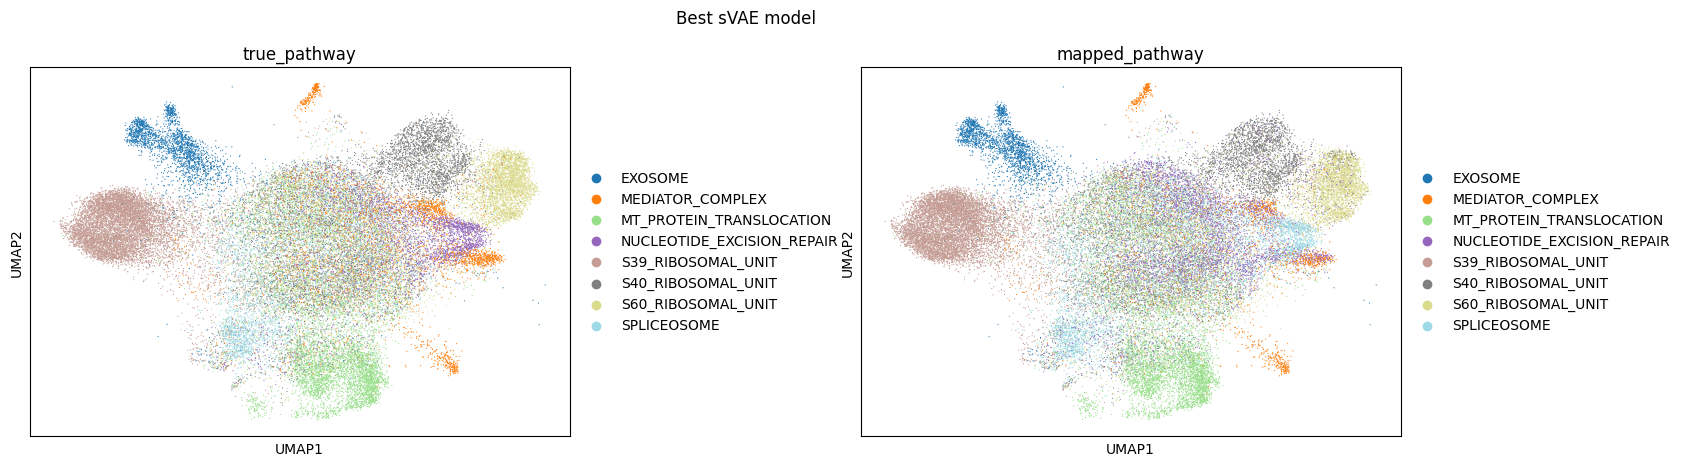


Generating figure for best cVAE model


/var/tmp/ipykernel_2642945/2831952657.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/cVAE_best_umap.png


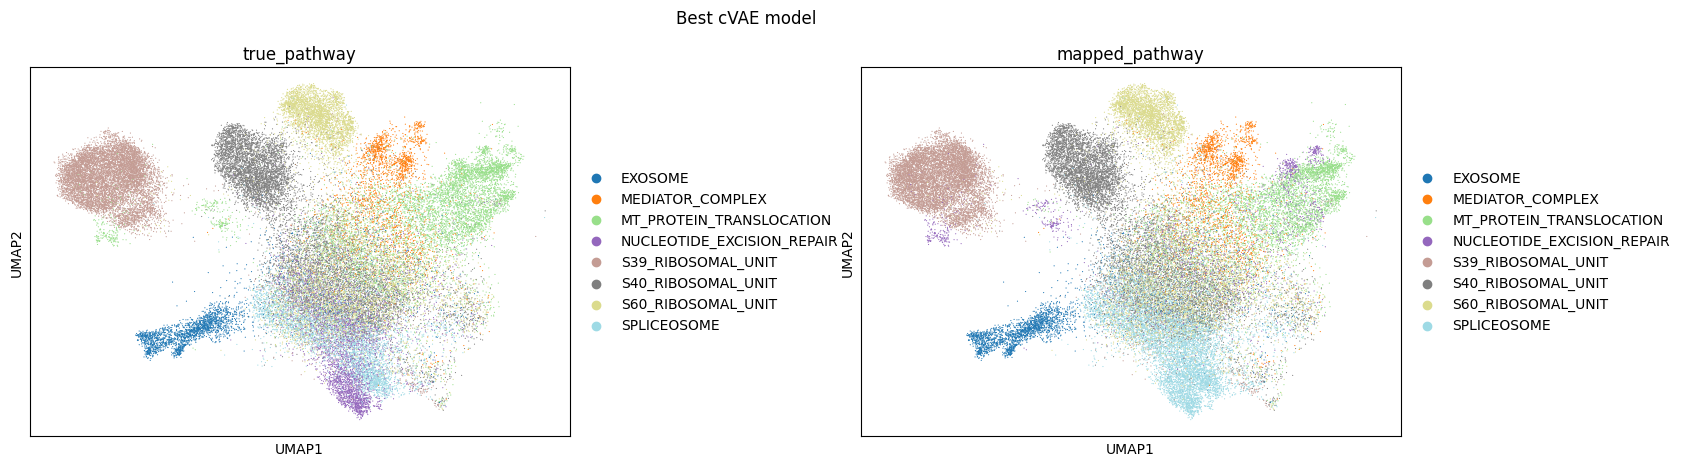


Generating figure for best contrastiveVI model


/var/tmp/ipykernel_2642945/2831952657.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/contrastiveVI_best_umap.png


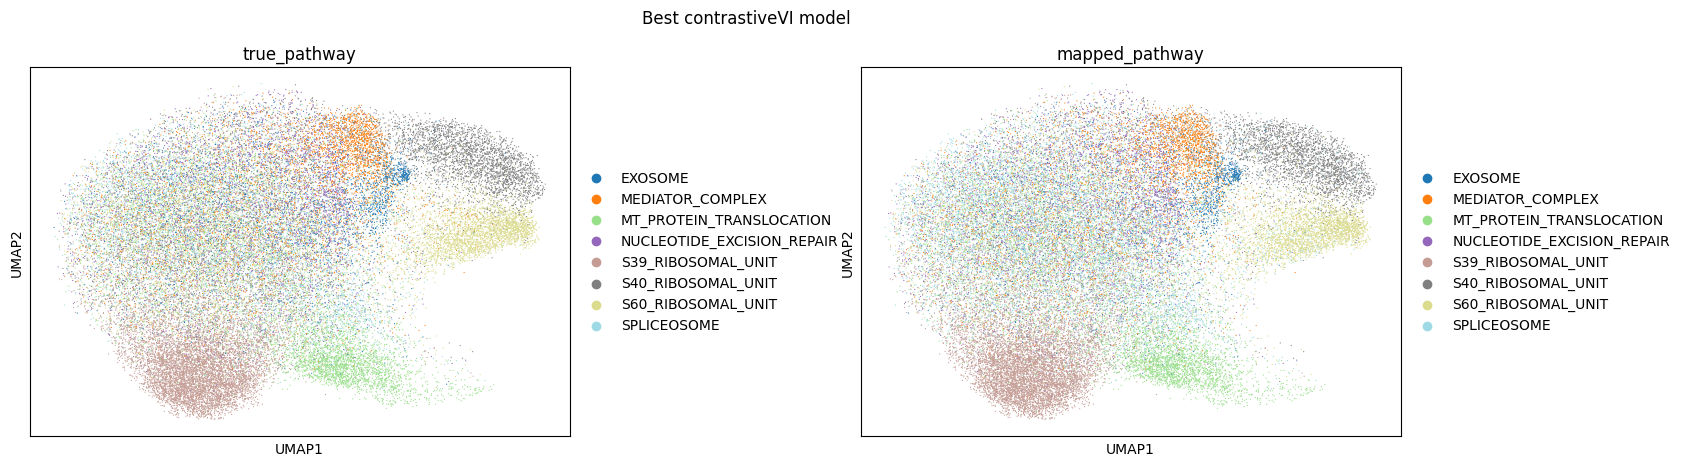


Generating figure for best scgen model


/var/tmp/ipykernel_2642945/2831952657.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))


  Saved → results/benchmarking/figures/scgen_best_umap.png


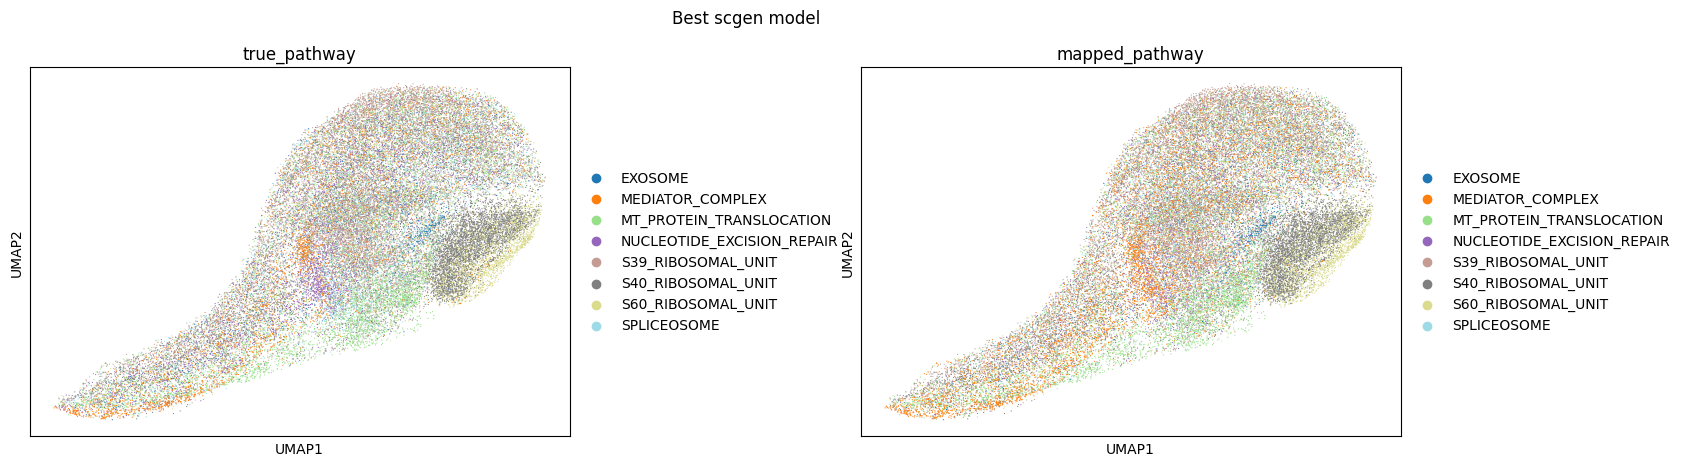

In [9]:
p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')

for method_name, model in best_run_model.items():
    print(f"\n{'='*60}\nGenerating figure for best {method_name} model\n{'='*60}")

    # Re-eval the best model for this method
    slk.tl.eval(model, data, obsm_key='z', uns_key='results', device=DEVICE)

    # UMAP on non-NTC cells
    sub = data[data.obs[p_key] != NTC].copy()
    sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
    sc.tl.umap(sub)

    # Cluster z_corr on pathway genes
    z_corr  = np.asarray(data.uns['results']['z_corr'])
    z_perts = np.asarray(data.uns['results']['z_perts'])

    pert_to_idx = {name: i for i, name in enumerate(z_perts)}
    valid_genes = [g for g in all_genes_filtered if g in pert_to_idx]
    gene_ids    = [pert_to_idx[g] for g in valid_genes]

    cov_subset = z_corr[np.ix_(gene_ids, gene_ids)]
    cov_subset = np.clip(cov_subset, -1.0, 1.0)
    cov_subset = 0.5 * (cov_subset + cov_subset.T)
    np.fill_diagonal(cov_subset, 1.0)

    groups = slk.tl.cluster_rho(data, t=N_CLUSTERS, rho_corr=cov_subset, criterion='maxclust', show=False)

    # Hungarian alignment of cluster → pathway labels
    clusters_df = pd.DataFrame({'gene': valid_genes, 'cluster': groups})
    pw_df = pathway_df_indexed.loc[pathway_df_indexed.index.isin(valid_genes)].reset_index()
    if 'gene' not in pw_df.columns:
        pw_df = pw_df.rename(columns={pathway_df_indexed.index.name or 'index': 'gene'})

    df_align  = pd.merge(clusters_df, pw_df, on='gene', how='inner')
    y_true    = df_align['pathway'].astype(str).values
    y_pred    = df_align['cluster'].astype(str).values
    true_lbl  = np.unique(y_true)
    pred_lbl  = np.unique(y_pred)

    C_mat = (
        pd.crosstab(df_align['pathway'].astype(str), df_align['cluster'].astype(str))
        .reindex(index=true_lbl, columns=pred_lbl, fill_value=0)
    )
    row_ind, col_ind = linear_sum_assignment(C_mat.values.max() - C_mat.values)
    mapping = {pred_lbl[j]: true_lbl[i] for i, j in zip(row_ind, col_ind)}
    df_align['mapped_pathway'] = [mapping.get(str(cl)) for cl in y_pred]

    # Subset z_sub to clustered genes and attach pathway labels
    clustered_genes = df_align['gene'].unique()
    z_sub = sub[sub.obs[p_key].isin(clustered_genes)].copy()

    gene_to_true   = dict(zip(df_align['gene'], df_align['pathway']))
    gene_to_mapped = dict(zip(df_align['gene'], df_align['mapped_pathway']))
    z_sub.obs['true_pathway']   = z_sub.obs[p_key].map(gene_to_true)
    z_sub.obs['mapped_pathway'] = z_sub.obs[p_key].map(gene_to_mapped)
    z_sub = z_sub[z_sub.obs['mapped_pathway'].notna()].copy()

    # Shared categorical palette across both columns
    all_cats  = pd.Index(np.unique(
        list(z_sub.obs['true_pathway'].dropna().unique()) +
        list(z_sub.obs['mapped_pathway'].dropna().unique())
    ).astype(str))
    cat_dtype = pd.api.types.CategoricalDtype(categories=all_cats, ordered=False)
    z_sub.obs['true_pathway']   = z_sub.obs['true_pathway'].astype('string').astype(cat_dtype)
    z_sub.obs['mapped_pathway'] = z_sub.obs['mapped_pathway'].astype('string').astype(cat_dtype)

    cmap_col       = plt.cm.get_cmap('tab20', len(all_cats))
    shared_palette = {cat: to_hex(cmap_col(i)) for i, cat in enumerate(all_cats)}
    z_sub.uns['true_pathway_colors']   = [shared_palette[c] for c in z_sub.obs['true_pathway'].cat.categories]
    z_sub.uns['mapped_pathway_colors'] = [shared_palette[c] for c in z_sub.obs['mapped_pathway'].cat.categories]

    # Plot and save
    fig = sc.pl.umap(
        z_sub,
        color=['true_pathway', 'mapped_pathway'],
        wspace=0.4,
        show=False,
        return_fig=True,
    )
    fig.suptitle(f'Best {method_name} model', y=1.02, fontsize=12)
    save_path = f'{RESULTS_DIR}/figures/{method_name}_best_umap.png'
    fig.savefig(save_path, bbox_inches='tight')
    print(f"  Saved → {save_path}")
    plt.show()